# NDVI Maker

---
- CELL — REAL NDVI FROM DJI M3M MULTISPECTRAL
- Ganti 'output_path' ke path Google Drive kamu
  -Contoh: '/content/drive/MyDrive/NDVI_Output/'

## Catatan penting:

- Kalau file TIF dari M3M sudah dalam format reflektance (nilai 0.0–1.0), hapus bagian normalisasi / 65535.0
- Kalau masih raw DN 16-bit, biarkan seperti itu
- Output: GeoTIFF bergeoreferensi + PNG preview dengan histogram distribusi NDVI

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Reading bands...
Creating georeference from EXIF...
[Georef] GSD: 2.94 cm/px | Alt: 183.8m | EPSG:32749
[Georef] Center → Lon:113.724439, Lat:-8.196475
Calculating NDVI...

[NDVI Stats]
  Min    : -0.7587
  Max    : 0.8110
  Mean   : 0.2066
  Median : 0.2140
  Healthy pixels (NDVI > 0.4): 668,238 (13.3%)

Saving GeoTIFF → /content/drive/MyDrive/DATASET TA/output/DJI_20260530085954_0001_NDVI.TIF


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


GeoTIFF saved ✓
Saving PNG preview → /content/drive/MyDrive/DATASET TA/output/DJI_20260530085954_0001_NDVI_preview.png


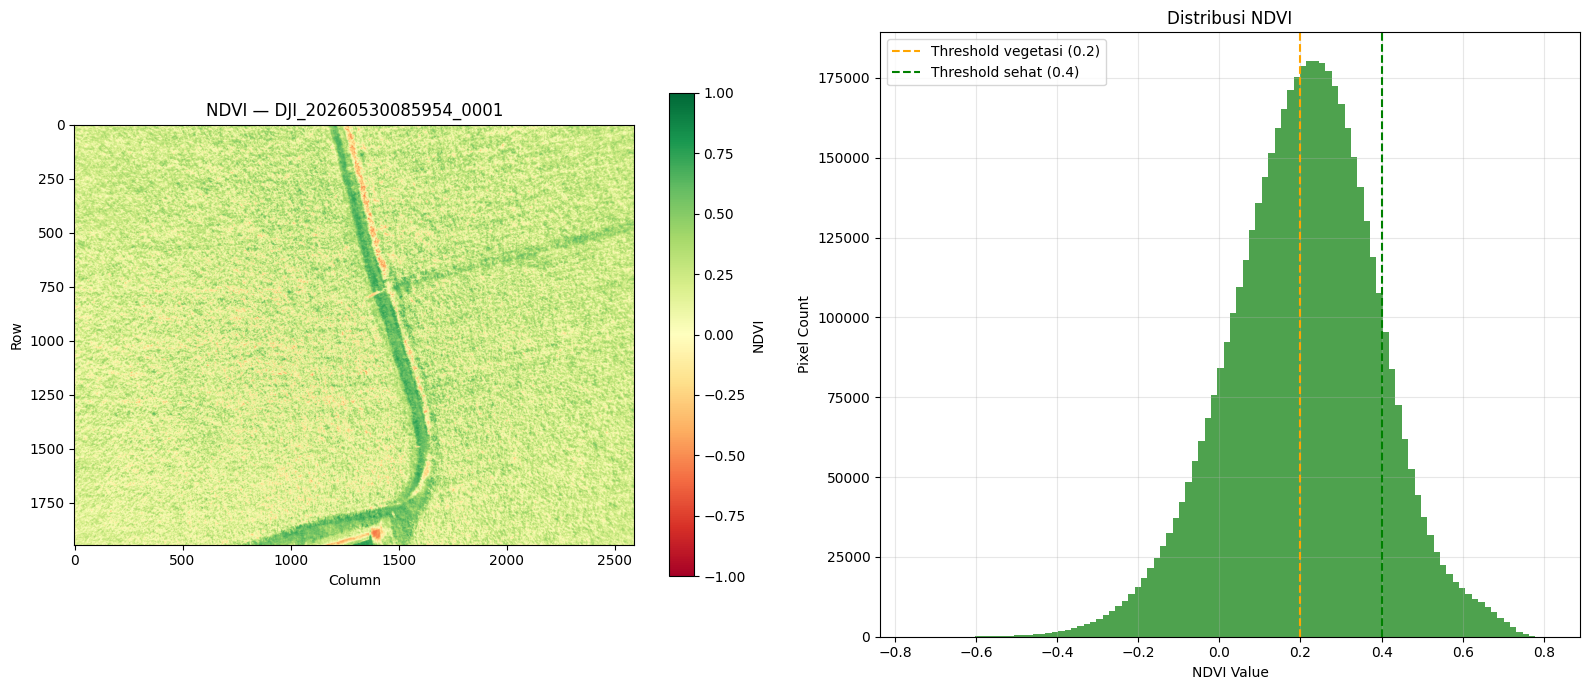


Done! Output tersimpan di: /content/drive/MyDrive/DATASET TA/output


In [8]:
import rasterio
from rasterio.transform import Affine
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
from pyproj import CRS, Transformer

# ============================================================
# ⚠️  GANTI BAGIAN INI
# ============================================================
image_directory = '/content/drive/MyDrive/DATASET TA/RAW>NDVI' # Folder file TIF + JPG
base_filename   = 'DJI_20260530085954_0001'           # Nama file base drone _D
output_path     = '/content/drive/MyDrive/DATASET TA/output'     # ← GANTI PATH DRIVE KAMU
# ============================================================

os.makedirs(output_path, exist_ok=True)

red_file         = os.path.join(image_directory, f"{base_filename}_MS_R.TIF")
nir_file         = os.path.join(image_directory, f"{base_filename}_MS_NIR.TIF")
jpg_file         = os.path.join(image_directory, f"{base_filename}_D.JPG")
output_ndvi_tif  = os.path.join(output_path, f"{base_filename}_NDVI.TIF")
output_ndvi_png  = os.path.join(output_path, f"{base_filename}_NDVI_preview.png")

# --- Helper ---
def dms_to_dd(dms, ref):
    d, m, s = dms
    s = float(s[0])/float(s[1]) if isinstance(s, tuple) else float(s)
    dd = float(d) + float(m)/60 + s/3600
    return dd * (-1 if ref in ['S', 'W'] else 1)

# --- Georeferencing dari EXIF ---
def get_georeference(jpg_path, width, height):
    with Image.open(jpg_path) as img:
        exif = img.getexif()
        gps  = {GPSTAGS.get(k,k): v for k,v in exif.get_ifd(0x8825).items()}
        exf  = {TAGS.get(k,k): v    for k,v in exif.get_ifd(0x8769).items()}

    lat = dms_to_dd(gps['GPSLatitude'],  gps['GPSLatitudeRef'])
    lon = dms_to_dd(gps['GPSLongitude'], gps['GPSLongitudeRef'])
    alt = gps['GPSAltitude'].numerator / gps['GPSAltitude'].denominator
    fl  = exf['FocalLength'].numerator  / exf['FocalLength'].denominator

    sensor_w = 5.1  # mm — DJI M3M sensor 1/2.3"
    gsd      = (alt * sensor_w) / (fl * width)  # meter/pixel

    zone     = int((lon + 180) / 6) + 1
    epsg     = 32700 + zone if lat < 0 else 32600 + zone
    utm_crs  = CRS.from_epsg(epsg)
    t        = Transformer.from_crs(CRS.from_epsg(4326), utm_crs, always_xy=True)
    cx, cy   = t.transform(lon, lat)

    tl_x = cx - (width  / 2) * gsd
    tl_y = cy + (height / 2) * gsd
    affine = Affine(gsd, 0.0, tl_x, 0.0, -gsd, tl_y)

    print(f"[Georef] GSD: {gsd*100:.2f} cm/px | Alt: {alt:.1f}m | EPSG:{epsg}")
    print(f"[Georef] Center → Lon:{lon:.6f}, Lat:{lat:.6f}")
    return affine, utm_crs, gsd

# --- Baca & normalisasi band ---
def read_band(path):
    with rasterio.open(path) as src:
        band = src.read(1).astype('float32')
        meta = src.meta.copy()
    return band, meta

# === MAIN ===
print("Reading bands...")
red, meta = read_band(red_file)
nir, _    = read_band(nir_file)

print("Creating georeference from EXIF...")
# transform, crs = get_georeference(jpg_file, meta['width'], meta['height'])
transform, crs, gsd = get_georeference(
    jpg_file,
    meta['width'],
    meta['height']
)

# Normalisasi DN ke reflektance (0–1) — M3M menyimpan DN 16-bit (0–65535)
# Jika file sudah dalam reflektance, skip bagian ini
red_r = np.clip(red / 65535.0, 0, 1)
nir_r = np.clip(nir / 65535.0, 0, 1)

# Hitung NDVI
print("Calculating NDVI...")
np.seterr(divide='ignore', invalid='ignore')
ndvi = np.where(
    (nir_r + red_r) == 0,
    np.nan,                                   # Piksel no-data → NaN
    (nir_r - red_r) / (nir_r + red_r)
)

# Statistik
valid = ndvi[~np.isnan(ndvi)]
print(f"\n[NDVI Stats]")
print(f"  Min    : {valid.min():.4f}")
print(f"  Max    : {valid.max():.4f}")
print(f"  Mean   : {valid.mean():.4f}")
print(f"  Median : {np.median(valid):.4f}")
print(f"  Healthy pixels (NDVI > 0.4): {(valid > 0.4).sum():,} ({(valid > 0.4).mean()*100:.1f}%)")

# Simpan GeoTIFF
print(f"\nSaving GeoTIFF → {output_ndvi_tif}")
meta.update(
    dtype='float32',
    count=1,
    nodata=np.nan,
    compress='lzw',
    transform=transform,
    crs=crs
)
with rasterio.open(output_ndvi_tif, 'w', **meta) as dst:
    dst.write(ndvi.astype('float32'), 1)
print("GeoTIFF saved ✓")

# Simpan PNG preview
print(f"Saving PNG preview → {output_ndvi_png}")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel kiri: NDVI map
im = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
fig.colorbar(im, ax=axes[0], label='NDVI', shrink=0.8)
axes[0].set_title(f'NDVI — {base_filename}', fontsize=12)
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')

# Panel kanan: Histogram distribusi
axes[1].hist(valid, bins=100, color='forestgreen', edgecolor='none', alpha=0.8)
axes[1].axvline(0.2, color='orange', linestyle='--', label='Threshold vegetasi (0.2)')
axes[1].axvline(0.4, color='green',  linestyle='--', label='Threshold sehat (0.4)')
axes[1].set_xlabel('NDVI Value')
axes[1].set_ylabel('Pixel Count')
axes[1].set_title('Distribusi NDVI')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_ndvi_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDone! Output tersimpan di: {output_path}")

In [9]:
# ============================================================
# NDVI CLASSIFICATION STATISTICS
# ============================================================

total_pixels = valid.size

non_veg = np.sum((valid >= -1.0) & (valid < 0.0))
sparse  = np.sum((valid >= 0.0) & (valid < 0.2))
moderate = np.sum((valid >= 0.2) & (valid < 0.5))
dense   = np.sum((valid >= 0.5) & (valid <= 1.0))

print("\n" + "="*60)
print("NDVI CLASSIFICATION SUMMARY")
print("="*60)

print(f"Non-Vegetated Surface  [-1.0, 0.0) : {non_veg:,} pixels ({non_veg/total_pixels*100:.2f}%)")
print(f"Sparse Vegetation      [0.0, 0.2)  : {sparse:,} pixels ({sparse/total_pixels*100:.2f}%)")
print(f"Moderate Vegetation    [0.2, 0.5)  : {moderate:,} pixels ({moderate/total_pixels*100:.2f}%)")
print(f"Dense Vegetation       [0.5, 1.0]  : {dense:,} pixels ({dense/total_pixels*100:.2f}%)")

print("="*60)
print(f"Total Valid Pixels : {total_pixels:,}")
print("="*60)


NDVI CLASSIFICATION SUMMARY
Non-Vegetated Surface  [-1.0, 0.0) : 636,083 pixels (12.62%)
Sparse Vegetation      [0.0, 0.2)  : 1,723,688 pixels (34.21%)
Moderate Vegetation    [0.2, 0.5)  : 2,447,344 pixels (48.57%)
Dense Vegetation       [0.5, 1.0]  : 231,733 pixels (4.60%)
Total Valid Pixels : 5,038,848


In [10]:
# ============================================================
# AREA ESTIMATION
# ============================================================

pixel_area = gsd * gsd  # m²

non_veg_area = non_veg * pixel_area
sparse_area = sparse * pixel_area
moderate_area = moderate * pixel_area
dense_area = dense * pixel_area

print("\nAREA ESTIMATION")
print("="*60)

print(f"Non-Vegetated Surface : {non_veg_area:.2f} m²")
print(f"Sparse Vegetation     : {sparse_area:.2f} m²")
print(f"Moderate Vegetation   : {moderate_area:.2f} m²")
print(f"Dense Vegetation      : {dense_area:.2f} m²")

print("="*60)
print(f"Total Area            : {(total_pixels*pixel_area):.2f} m²")
print(f"Total Area            : {(total_pixels*pixel_area)/10000:.4f} ha")


AREA ESTIMATION
Non-Vegetated Surface : 551.07 m²
Sparse Vegetation     : 1493.30 m²
Moderate Vegetation   : 2120.24 m²
Dense Vegetation      : 200.76 m²
Total Area            : 4365.36 m²
Total Area            : 0.4365 ha
